## EV Route Finding System

## Initial Neighbor Finding Code

In [1]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import deque,defaultdict
import math
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [3]:
# Keep only stations with valid coordinates and charger counts
df = pd.read_csv("./ev-charging-station.csv")
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'EV Level2 EVSE Num', 'EV Connector Types']).reset_index(drop=True)
df_clean['EV Level2 EVSE Num'] = df_clean['EV Level2 EVSE Num'].astype(int)

# Parse connector types into sets
df_clean['connector_set'] = df_clean['EV Connector Types'].apply(lambda x: set(map(str.strip, x.split(','))) if isinstance(x, str) else set())

# Clustering
coords = df_clean[['Latitude', 'Longitude']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 30.0 / kms_per_radian  # ~20 km radius
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
df_clean['cluster'] = db.labels_

# Group by cluster and aggregate
df_clustered = df_clean.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'EV Level2 EVSE Num': 'sum',
    'connector_set': lambda sets: set().union(*sets)
}).reset_index(drop=True)

G = nx.Graph()
for idx, row in df_clustered.iterrows():
    G.add_node(
        idx,
        pos=(row['Latitude'], row['Longitude']),
        chargers=row['EV Level2 EVSE Num'],
        connector_types=row['connector_set']
    )

def distance(i, j):
    return geodesic(G.nodes[i]['pos'], G.nodes[j]['pos']).km

def angle_between(lat1, lon1, lat2, lon2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    angle = math.degrees(math.atan2(dlon, dlat)) % 360
    return angle

# number of nearest neighbors per node
k = 5

print("Graph node count:", len(G.nodes))
print("Connecting each node to its", k, "nearest neighbors...")

for i in G.nodes:
    distances = []
    lat1, lon1 = G.nodes[i]['pos']

    for j in G.nodes:
        if i == j:
            continue
        lat2, lon2 = G.nodes[j]['pos']
        dist = distance(i, j)
        distances.append((dist, j))

    distances.sort()
    nearest_neighbors = [j for _, j in distances[:k]]

    for j in nearest_neighbors:
        dist = distance(i, j)
        weight = dist / (1 + G.nodes[j]['chargers'])
        G.add_edge(i, j, weight=weight)

    print(f"Node {i} → Neighbors: {nearest_neighbors}")

# Save
with open("graph_data_30km.gpickle", "wb") as f:
    pickle.dump(G, f)

C:\Users\Sarvesh Ram Kumar\AppData\Local\Temp\ipykernel_13372\1780264478.py:2: DtypeWarning: Columns (5,6,26,38,48,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./ev-charging-station.csv")


Graph node count: 1184
Connecting each node to its 5 nearest neighbors...
Node 0 → Neighbors: [62, 686, 370, 54, 613]
Node 1 → Neighbors: [998, 1167, 1138, 1056, 313]
Node 2 → Neighbors: [347, 882, 374, 1009, 145]
Node 3 → Neighbors: [471, 681, 441, 219, 946]
Node 4 → Neighbors: [335, 161, 191, 615, 1182]
Node 5 → Neighbors: [497, 583, 222, 65, 177]
Node 6 → Neighbors: [994, 609, 389, 680, 1069]
Node 7 → Neighbors: [832, 504, 392, 271, 114]
Node 8 → Neighbors: [649, 958, 439, 267, 1055]
Node 9 → Neighbors: [730, 625, 953, 719, 597]
Node 10 → Neighbors: [470, 717, 662, 988, 551]
Node 11 → Neighbors: [182, 1084, 1073, 607, 400]
Node 12 → Neighbors: [282, 614, 429, 964, 901]
Node 13 → Neighbors: [901, 1119, 857, 844, 282]
Node 14 → Neighbors: [640, 1101, 847, 702, 580]
Node 15 → Neighbors: [143, 186, 1129, 215, 351]
Node 16 → Neighbors: [914, 385, 154, 70, 384]
Node 17 → Neighbors: [1065, 239, 328, 483, 140]
Node 18 → Neighbors: [270, 1080, 832, 646, 218]
Node 19 → Neighbors: [89, 526, 11

In [4]:
# Load
with open("graph_data_30km.gpickle", "rb") as f:
    G = pickle.load(f)

## The Environment the Car is going to work upon and Double Q-Learning Algorithm

In [5]:
class EVRouteEnv:
    def __init__(self, graph, start, goal, preferred_connector_type=None):
        self.graph = graph
        self.start = start
        self.goal = goal
        self.preferred_connector_type = preferred_connector_type
        self.reset()

    def reset(self):
        self.state = self.start
        self.visited = {self.start}
        self.steps = 0
        self.distance = 0
        self.visit_counts = defaultdict(int)
        return self.state

    def step(self, action):
        if action not in self.graph[self.state]:
            return self.state, -10, 10, False  # penalty + high "cost"

        self.steps += 1
        prev_pos = self.graph.nodes[self.state]['pos']
        next_pos = self.graph.nodes[action]['pos']
        dist = geodesic(prev_pos, next_pos).km
        self.distance += dist

        # ---- base reward and cost ----
        reward = -dist            # smaller distance = higher reward
        cost = dist               # cost = travel distance

        # connector-aware bonus / penalty
        node_data = self.graph.nodes[action]
        if node_data.get('chargers', 0) > 0:
            connectors = node_data.get('connector_types', [])
            if self.preferred_connector_type in connectors:
                reward += 10
            else:
                reward -= 3

        # progress toward goal
        prev_goal = geodesic(prev_pos, self.graph.nodes[self.goal]['pos']).km
        new_goal = geodesic(next_pos, self.graph.nodes[self.goal]['pos']).km
        reward += 0.5 * (prev_goal - new_goal)

        # delay + loop penalties
        reward -= min(0.01 * (1.05 ** self.steps), 900)
        if action in self.visited:
            visits = self.visit_counts.get(action, 1)
            reward -= 100 * visits
            cost += 5 * visits  # add to cost too
            self.visit_counts[action] = visits + 1
        else:
            self.visit_counts[action] = 1

        self.state = action
        self.visited.add(action)

        done = self.state == self.goal
        if done:
            reward += 10000

        return self.state, reward, cost, done

    def get_actions(self, state):
        return list(self.graph[state])


# ---------- DUAL-Q AGENT ----------
class DualQAgent:
    def __init__(self, graph, alpha=0.1, gamma=0.9, epsilon=0.2,
                 mu=0.05, target_cost=5.0, mu_lr=0.01):
        self.graph = graph
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.mu = mu                   # adaptive weight between reward and cost
        self.target_cost = target_cost # desired average travel cost per step
        self.mu_lr = mu_lr             # learning rate for μ
        self.QR = defaultdict(float)
        self.QC = defaultdict(float)

    def choose_action(self, state, actions):
        if random.random() < self.epsilon:
            return random.choice(actions)
        scores = []
        for a in actions:
            q_r = self.QR[(state, a)]
            q_c = self.QC[(state, a)]
            score = q_r - self.mu * q_c
            scores.append(score)
        return actions[int(np.argmax(scores))]

    def learn(self, s, a, r, c, s_next, actions_next, done):
        # --- choose next greedy actions ---
        if actions_next:
            best_a_r = max(actions_next, key=lambda x: self.QR[(s_next, x)])
            best_a_c = max(actions_next, key=lambda x: self.QC[(s_next, x)])
        else:
            best_a_r = best_a_c = a

        # --- TD targets ---
        target_r = r + (0 if done else self.gamma * self.QR[(s_next, best_a_r)])
        target_c = c + (0 if done else self.gamma * self.QC[(s_next, best_a_c)])

        # --- Q-table updates ---
        self.QR[(s,a)] += self.alpha * (target_r - self.QR[(s,a)])
        self.QC[(s,a)] += self.alpha * (target_c - self.QC[(s,a)])

        # --- Adaptive μ update (principled) ---
        # μ increases if cost exceeds target_cost, decreases if below
        cost_error = c - self.target_cost
        self.mu += self.mu_lr * cost_error
        self.mu = float(np.clip(self.mu, 0.01, 1.0))  # keep stable bounds


def find_nearest_node(lat, lon):
    return min(G.nodes, key=lambda n: geodesic((lat, lon), G.nodes[n]['pos']).km)

## Training on the Dataset with 600 Episodes with Starting and Destination Locations

In [6]:
# ---------- TRAINING LOOP FOR DUAL-Q ADAPTIVE μ AGENT ----------

start_lat, start_lon = 37.77, -122.41
end_lat, end_lon = 45.51, -122.67

start_node = find_nearest_node(start_lat, start_lon)
goal_node = find_nearest_node(end_lat, end_lon)

env = EVRouteEnv(G, start_node, goal_node, preferred_connector_type='J1772')
agent = DualQAgent(G, alpha=0.1, gamma=0.9, epsilon=0.2, mu=0.05)

max_steps = 10000
episodes = 600

# Adaptive μ parameters
target_total_cost = 900.0   # desired average trip distance (km)
mu_lr = 0.001                # learning rate for μ adjustment

# Tracking
episode_distances = []
episode_rewards = []
episode_steps = []
episode_mus = []

for episode in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0.0
    total_cost = 0.0
    steps = 0

    # ---- Run one episode ----
    while not done and steps < max_steps:
        actions = env.get_actions(state)
        if not actions:
            break  # dead-end node

        action = agent.choose_action(state, actions)
        next_state, reward, cost, done = env.step(action)

        next_actions = env.get_actions(next_state)
        agent.learn(state, action, reward, cost, next_state, next_actions, done)

        total_reward += reward
        total_cost += cost
        state = next_state
        steps += 1

    # ---- Adaptive μ update (per episode) ----
    cost_error = total_cost - target_total_cost
    agent.mu += mu_lr * cost_error
    agent.mu = float(np.clip(agent.mu, 0.01, 1.0))

    # ---- Log metrics ----
    episode_distances.append(total_cost)
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    episode_mus.append(agent.mu)

    print(f"Episode {episode+1:03d} | "
          f"Distance = {total_cost:10.2f} km | "
          f"Steps = {steps:5d} | "
          f"Reward = {total_reward:10.2f} | "
          f"μ = {agent.mu:6.4f}")


Episode 001 | Distance =   10505.12 km | Steps =    87 | Reward =  -18115.19 | μ = 1.0000
Episode 002 | Distance =   24783.65 km | Steps =   228 | Reward =  -67142.79 | μ = 1.0000
Episode 003 | Distance =  339992.34 km | Steps =  2964 | Reward = -3625020.55 | μ = 1.0000
Episode 004 | Distance =   11867.85 km | Steps =   108 | Reward =  -16120.07 | μ = 1.0000
Episode 005 | Distance =    3763.41 km | Steps =    35 | Reward =    5544.01 | μ = 1.0000
Episode 006 | Distance =    1668.04 km | Steps =    12 | Reward =    8749.17 | μ = 1.0000
Episode 007 | Distance =    1687.03 km | Steps =    17 | Reward =    8387.07 | μ = 1.0000
Episode 008 | Distance =    9796.57 km | Steps =    85 | Reward =   -7558.27 | μ = 1.0000
Episode 009 | Distance =    3104.71 km | Steps =    31 | Reward =    5208.92 | μ = 1.0000
Episode 010 | Distance =    9066.51 km | Steps =    81 | Reward =  -12535.86 | μ = 1.0000
Episode 011 | Distance =    2777.44 km | Steps =    28 | Reward =    5981.32 | μ = 1.0000
Episode 0

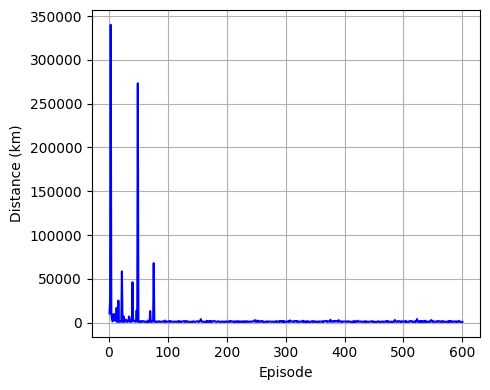

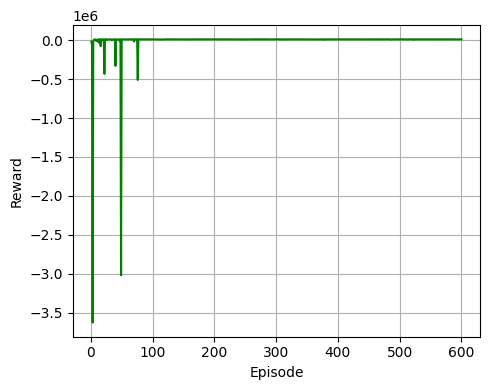

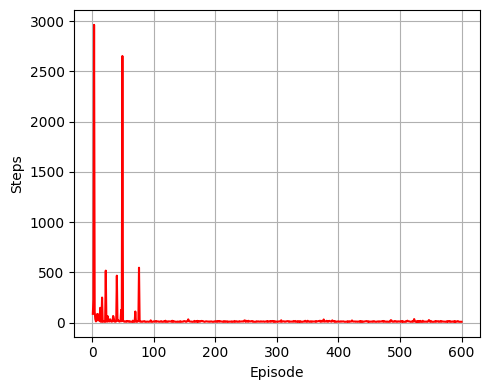

In [7]:
import matplotlib.pyplot as plt

episodes = range(1, len(episode_distances) + 1)

# 1. Distance Plot
plt.figure(figsize=(5, 4))
plt.plot(episodes, episode_distances, color='blue')
plt.xlabel("Episode")
plt.ylabel("Distance (km)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Reward Plot
plt.figure(figsize=(5, 4))
plt.plot(episodes, episode_rewards, color='green')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Steps Plot
plt.figure(figsize=(5, 4))
plt.plot(episodes, episode_steps, color='red')
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.tight_layout()
plt.show()


## Filtering Nodes Selected

In [8]:
def filter_path_by_distance(path, graph, min_km=175, max_km=225):
    if not path or len(path) < 2:
        return path

    filtered_path = [path[0]]
    current = path[0]
    i = 1

    while i < len(path):
        found = False
        for j in range(i, len(path)):
            dist = geodesic(graph.nodes[current]['pos'], graph.nodes[path[j]]['pos']).km
            if min_km <= dist <= max_km:
                filtered_path.append(path[j])
                current = path[j]
                i = j + 1
                found = True
                break
        if not found:
            filtered_path.append(path[i])
            current = path[i]
            i += 1

    return filtered_path


## Testing with the same route to get results

In [9]:
from geopy.distance import geodesic

# ---- Greedy Evaluation Phase ----
agent.epsilon = 0.0   # Greedy: no random exploration

# Reset environment
state = env.reset()
path = [state]
step_counter = 0
max_steps = 1000  

# Save route coordinates to file
with open("ev_route_coordinates_dual_q_30km.txt", "w") as f:
    done = False
    lat, lon = G.nodes[start_node]['pos']
    f.write(f"{lon},{lat}\n")

    while not done and step_counter < max_steps:
        actions = env.get_actions(state)
        if not actions:
            print("No further actions available. Route terminated early.")
            break

        # Greedy action selection
        action = agent.choose_action(state, actions)
        
        # Environment step (returns reward, cost, done)
        next_state, reward, cost, done = env.step(action)

        path.append(next_state)
        lat, lon = G.nodes[next_state]['pos']
        f.write(f"{lon},{lat}\n")

        print(f"Step {step_counter + 1}: → Node {next_state} | "
              f"Reward = {reward:7.2f} | Cost = {cost:6.2f} km | μ = {agent.mu:5.3f}")

        state = next_state
        step_counter += 1

print("\n✅ Route completed.")
print(f"Total distance traveled: {env.distance:.2f} km")

# ---- Final destination check ----
goal_lat, goal_lon = G.nodes[env.goal]['pos']
final_lat, final_lon = G.nodes[state]['pos']
remaining_dist = geodesic((final_lat, final_lon), (goal_lat, goal_lon)).km

print(f"Reached node: {state}")
print(f"Goal node: {env.goal}")
print(f"Distance to goal: {remaining_dist:.2f} km")

if remaining_dist < 5.0:
    print("🏁 Agent successfully reached the goal.")
else:
    print("⚠️ Agent did NOT reach the goal accurately.")


Step 1: → Node 615 | Reward =  -70.04 | Cost = 159.73 km | μ = 0.967
Step 2: → Node 80 | Reward =  -68.70 | Cost = 156.98 km | μ = 0.967
Step 3: → Node 276 | Reward =  -29.85 | Cost =  79.04 km | μ = 0.967
Step 4: → Node 137 | Reward =  -54.79 | Cost = 113.56 km | μ = 0.967
Step 5: → Node 183 | Reward =  -16.83 | Cost =  53.42 km | μ = 0.967
Step 6: → Node 570 | Reward =  -52.18 | Cost = 122.81 km | μ = 0.967
Step 7: → Node 664 | Reward =  -34.48 | Cost =  52.07 km | μ = 0.967
Step 8: → Node 27 | Reward = 9945.46 | Cost = 129.06 km | μ = 0.967

✅ Route completed.
Total distance traveled: 866.68 km
Reached node: 27
Goal node: 27
Distance to goal: 0.00 km
🏁 Agent successfully reached the goal.


## Geodesic Analysis

In [10]:
print("Geodesic Analysis")

# To find the final accuaracy comparing the original actual distances with the travelled distance by the car
actual_geodesic = geodesic(G.nodes[start_node]['pos'], G.nodes[goal_node]['pos']).km
efficiency = actual_geodesic / env.distance
print(f"Accuracy (efficiency): {efficiency:.2%}")

filtered_path = filter_path_by_distance(path, G)
print(f"\nFiltered Path (hops 175–225 km): {filtered_path}")

filtered_distance = sum(
    geodesic(G.nodes[filtered_path[i]]['pos'], G.nodes[filtered_path[i + 1]]['pos']).km
    for i in range(len(filtered_path) - 1)
)
#print(f"Filtered path total distance: {filtered_distance:.2f} km")

filtered_efficiency = actual_geodesic / filtered_distance
print(f"Filtered Accuracy (efficiency): {filtered_efficiency:.2%}")

# Save filtered path coordinates to a text file
with open("ev-routing-coordinates-dual-q-filtering_30km.txt", "w") as f:
    for node in filtered_path:
        lat, lon = G.nodes[node]['pos']  # assuming 'pos' is in (lat, lon) format
        f.write(f"{lon},{lat}\n") 

print("\nOn-Road Distance Comparison")
on_road=1020
print(f"Actual Accuracy:{(on_road/env.distance):.2%}")

Geodesic Analysis
Accuracy (efficiency): 96.55%

Filtered Path (hops 175–225 km): [4, 615, 80, 137, 570, 664, 27]
Filtered Accuracy (efficiency): 96.83%

On-Road Distance Comparison
Actual Accuracy:117.69%


## On-Road Distance Analysis(Actual Accuracy of the Model) using ORS:

Route from point 0 to 1: 191882.40 m
Route from point 1 to 2: 166889.10 m
Route from point 2 to 3: 100120.20 m
Route from point 3 to 4: 133511.80 m
Route from point 4 to 5: 57146.30 m
Route from point 5 to 6: 187133.70 m
Route from point 6 to 7: 122233.40 m
Route from point 7 to 8: 219630.00 m

✅ Total real-world road distance: 1178.55 km


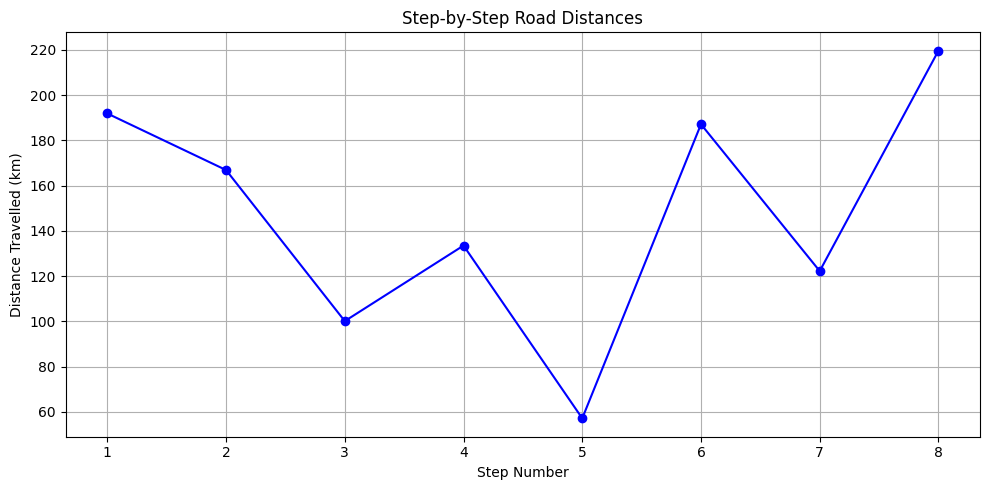

In [ ]:
import openrouteservice

# Replace with your actual OpenRouteService API key
ORS_API_KEY = "API-Key"

# Load coordinates (in (lat, lon) format)
coords = []
with open("ev_route_coordinates_dual_q_30km.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        coords.append((lon, lat))  # ORS expects (lon, lat)

# Initialize ORS client
client = openrouteservice.Client(key=ORS_API_KEY)

# Calculate total road distance
total_distance = 0
start_idx = 0
step_distances = []

for end_idx in range(1, len(coords)):
    try:
        res = client.directions(
            coordinates=[coords[start_idx], coords[end_idx]],
            profile='driving-car',
            format='geojson',
            radiuses=[1000, 1000]
        )
        dist = res['features'][0]['properties']['segments'][0]['distance']  # in meters
        total_distance += dist
        step_distances.append(dist / 1000)  # convert to kilometers
        print(f"Route from point {start_idx} to {end_idx}: {dist:.2f} m")

        start_idx = end_idx  # Move to next valid start point
    except Exception as e:
        print(f"⚠️ No route from point {start_idx} to {end_idx}: skipping point {end_idx}")

print(f"\n✅ Total real-world road distance: {total_distance/1000:.2f} km")

# Plot step-wise distances
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(step_distances)+1), step_distances, marker='o', linestyle='-', color='blue')
plt.title("Step-by-Step Road Distances")
plt.xlabel("Step Number")
plt.ylabel("Distance Travelled (km)")
plt.grid(True)
plt.xticks(range(1, len(step_distances)+1))
plt.tight_layout()
plt.show()


## Finding the Actual Accuracy of the Model

In [12]:
on_road_distance = 1020
total_distance=total_distance/1000
actual_accuracy = on_road_distance / total_distance
print(f"Actual Accuracy (Efficiency): {actual_accuracy:.2%}")

Actual Accuracy (Efficiency): 86.55%


## Plotting with Filtering

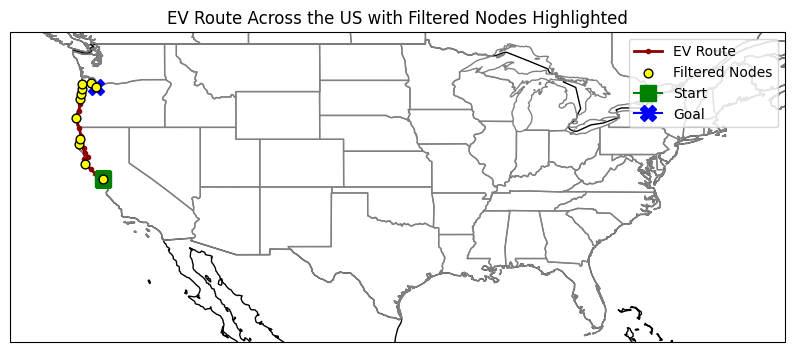

In [ ]:
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load full route coordinates
route_coords = []
with open("ev_route_coordinates_dual_q_30km.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        route_coords.append((lon, lat))

# Load filtered node positions (from graph G using node IDs)
filtered_coords = [G.nodes[n]['pos'] for n in filtered_path]
filtered_lats, filtered_lons = zip(*filtered_coords)

# Split full route coords
lons, lats = zip(*route_coords)

# Set up map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES, edgecolor='gray')

# Plot full route
ax.plot(lons, lats, marker='o', color='darkred', linewidth=2, markersize=3, label='EV Route')

# Highlight filtered path nodes
ax.scatter(filtered_lons, filtered_lats, color='yellow', edgecolor='black', s=40, zorder=5, label='Filtered Nodes')

# Mark start and goal
ax.plot(lons[0], lats[0], marker='s', color='green', markersize=12, label='Start')
ax.plot(lons[-1], lats[-1], marker='X', color='blue', markersize=12, label='Goal')

plt.title("EV Route Across the US with Filtered Nodes Highlighted")
plt.legend()
plt.show()
